## Environment Setup
This notebook requires TensorFlow, TensorBoard, and Matplotlib. Install them if they are not already available in your Python environment.

In [1]:
# Core libraries used throughout this notebook
import tensorflow as tf
import tensorboard
import matplotlib.pyplot as plt
from datetime import datetime

## 1. Tensor Manipulations & Reshaping
### Task: Tensor Reshaping & Operations
This task demonstrates how TensorFlow represents and manipulates multidimensional data using tensors. A random tensor is created to provide sample data for practicing tensor operations. Its rank and shape are examined to understand its dimensions, then reshaping and transposing are used to demonstrate how the same data can be reorganized for different computational needs. Finally, broadcasting shows how TensorFlow can perform operations between tensors of different but compatible shapes.

In [2]:
# 1. Create a random tensor with shape (4, 6).
# This gives us a simple 2D tensor to practice tensor operations on.
# The tensor has 4 rows and 6 columns, giving a total of 24 values.
tensor = tf.random.uniform(shape=(4, 6))

print("Original Tensor:")
print(tensor)


# 2. Find its rank and shape using TensorFlow functions.
# Rank tells us how many dimensions the tensor has.
# Shape tells us the size of each dimension.
# These are important because many tensor operations depend on dimensions matching correctly.
print("\nOriginal Rank:", tf.rank(tensor).numpy())
print("Original Shape:", tf.shape(tensor).numpy())


# 3. Reshape the tensor from (4, 6) to (2, 3, 4) and transpose it to (3, 2, 4).
# Reshaping changes how the same data is organized without changing the actual values.
# We can do this because both shapes contain the same number of elements: 4 × 6 = 24 and 2 × 3 × 4 = 24.
reshaped_tensor = tf.reshape(tensor, shape=(2, 3, 4))

print("\nReshaped Tensor:")
print(reshaped_tensor)

print("Rank after reshaping:", tf.rank(reshaped_tensor).numpy())
print("Shape after reshaping:", tf.shape(reshaped_tensor).numpy())


# Transpose the reshaped tensor from (2, 3, 4) to (3, 2, 4).
# Transposing changes the order of the tensor's dimensions.
# This is useful when another operation or model layer expects the dimensions to appear in a different order.
transposed_tensor = tf.transpose(
    reshaped_tensor,
    perm=[1, 0, 2]
)

print("\nTransposed Tensor:")
print(transposed_tensor)

print("Rank after transpose:", tf.rank(transposed_tensor).numpy())
print("Shape after transpose:", tf.shape(transposed_tensor).numpy())


# 4. Create a smaller tensor with shape (1, 4).
# This tensor will be expanded to match the shape of the larger tensor.
small_tensor = tf.random.uniform(shape=(1, 4))


# Broadcast the smaller tensor from (1, 4) to match the larger tensor (3, 2, 4).
# Broadcasting expands the smaller tensor across compatible dimensions so that it has the same shape as the larger tensor.
broadcasted_tensor = tf.broadcast_to(
    small_tensor,
    tf.shape(transposed_tensor)
)


# Add the two tensors now that they have matching shapes.
result = transposed_tensor + broadcasted_tensor

print("\nSmall Tensor Shape:", tf.shape(small_tensor).numpy())
print("Broadcasted Tensor Shape:", tf.shape(broadcasted_tensor).numpy())
print("Result Shape:", tf.shape(result).numpy())

Original Tensor:
tf.Tensor(
[[0.23325801 0.11120105 0.7905899  0.67609525 0.25498664 0.29881966]
 [0.5478189  0.3053589  0.70346725 0.6117513  0.88941014 0.63795197]
 [0.7029518  0.09994543 0.6286087  0.41309822 0.8990053  0.40678763]
 [0.6488426  0.08229303 0.1546309  0.24073076 0.4905194  0.9822203 ]], shape=(4, 6), dtype=float32)

Original Rank: 2
Original Shape: [4 6]

Reshaped Tensor:
tf.Tensor(
[[[0.23325801 0.11120105 0.7905899  0.67609525]
  [0.25498664 0.29881966 0.5478189  0.3053589 ]
  [0.70346725 0.6117513  0.88941014 0.63795197]]

 [[0.7029518  0.09994543 0.6286087  0.41309822]
  [0.8990053  0.40678763 0.6488426  0.08229303]
  [0.1546309  0.24073076 0.4905194  0.9822203 ]]], shape=(2, 3, 4), dtype=float32)
Rank after reshaping: 3
Shape after reshaping: [2 3 4]

Transposed Tensor:
tf.Tensor(
[[[0.23325801 0.11120105 0.7905899  0.67609525]
  [0.7029518  0.09994543 0.6286087  0.41309822]]

 [[0.25498664 0.29881966 0.5478189  0.3053589 ]
  [0.8990053  0.40678763 0.6488426  0.0


### How broadcasting works in TensorFlow:
Broadcasting allows TensorFlow to perform operations on tensors with different shapes by automatically expanding the smaller tensor across compatible dimensions.
Here, the small tensor has shape (1, 4), while the larger tensor has shape (3, 2, 4).
TensorFlow treats the smaller tensor as if it were repeated across the first two dimensions until it matches (3, 2, 4), allowing element-wise addition.
Broadcasting is useful because it avoids writing loops or manually copying values, making tensor operations simpler and more efficient.

# 2. Loss Functions & Hyperparameter Tuning
### Task: Implement and Compare Loss Functions
In this task, y_true and y_pred are manually defined so that the behavior of the loss functions can be studied under controlled conditions. Rather than training a model to generate predictions, known prediction values are used and then modified to observe how Mean Squared Error (MSE) and Categorical Cross-Entropy (CCE) respond to changes in prediction accuracy. In a trained neural network, y_true would normally come from the dataset, while y_pred would be generated by the model.

Original Predictions
MSE Loss: 0.32666668
CCE Loss: 1.6539484

Modified Predictions
MSE Loss: 0.06888888
CCE Loss: 0.45944205


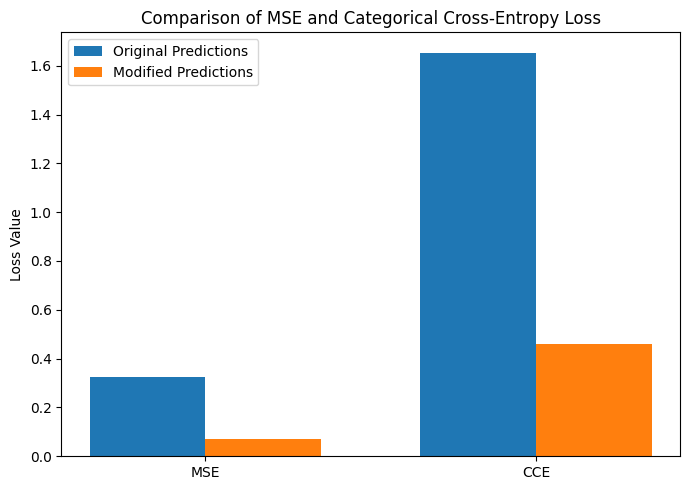

In [3]:
# 1. Define true values (y_true) and model predictions (y_pred).
# Each row represents one sample, while each column represents one class.
# y_true uses one-hot encoding, where the correct class is represented by 1.
# y_pred contains the model's predicted probabilities for the three classes.
# The probabilities in each row sum to 1 (100%).
y_true = tf.constant([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0]
])

y_pred = tf.constant([
    [0.10, 0.10, 0.80],
    [0.20, 0.70, 0.10],
    [0.70, 0.20, 0.10]
])


# 2. Compute Mean Squared Error (MSE) and Categorical Cross-Entropy (CCE) losses.
# MSE measures the average squared difference between the true values and the predicted values.
#
# Categorical Cross-Entropy measures how well the predicted probability distribution matches the correct class in a multi-class problem.
mse_loss = tf.keras.losses.MeanSquaredError()
cce_loss = tf.keras.losses.CategoricalCrossentropy()


# Compute the original loss values.
original_mse = mse_loss(y_true, y_pred)
original_cce = cce_loss(y_true, y_pred)

print("Original Predictions")
print("MSE Loss:", original_mse.numpy())
print("CCE Loss:", original_cce.numpy())


# 3. Modify predictions slightly and check how loss values change (while keeping each row's total equal to 1).
# This allows us to compare how MSE and CCE respond when the model's predicted probabilities change.
y_pred_modified = tf.constant([
    [0.70, 0.20, 0.10],
    [0.20, 0.60, 0.20],
    [0.20, 0.20, 0.60]
])


# Compute the loss values again using the modified predictions.
modified_mse = mse_loss(y_true, y_pred_modified)
modified_cce = cce_loss(y_true, y_pred_modified)

print("\nModified Predictions")
print("MSE Loss:", modified_mse.numpy())
print("CCE Loss:", modified_cce.numpy())


# 4. Plot loss function values using Matplotlib.
# A grouped bar chart makes it easier to compare how both loss functions respond to the original and modified predictions.
import matplotlib.pyplot as plt

loss_names = ["MSE", "CCE"]

original_losses = [
    original_mse.numpy(),
    original_cce.numpy()
]

modified_losses = [
    modified_mse.numpy(),
    modified_cce.numpy()
]

x = range(len(loss_names))
bar_width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(
    [i - bar_width / 2 for i in x],
    original_losses,
    width=bar_width,
    label="Original Predictions"
)

plt.bar(
    [i + bar_width / 2 for i in x],
    modified_losses,
    width=bar_width,
    label="Modified Predictions"
)

plt.xticks(x, loss_names)
plt.ylabel("Loss Value")
plt.title("Comparison of MSE and Categorical Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Observation
The modified predictions produced lower loss values than the original predictions. MSE decreased from approximately 0.327 to 0.069, while CCE decreased from approximately 1.654 to 0.459. This indicates that the modified predictions were overall closer to the true class labels. Therefore, the lower loss values show that the modified predictions performed better overall.

## 3. Train a Model with Different Optimizers
### Task: Train MNIST Model with Adam & SGD
This task compares how two different optimizers, Adam and SGD, affect the training of a neural network on the MNIST handwritten-digit dataset. Both models use the same dataset and model structure, so that their training and validation accuracy can be compared fairly.

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9165 - loss: 0.2900 - val_accuracy: 0.9548 - val_loss: 0.1618
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9618 - loss: 0.1319 - val_accuracy: 0.9690 - val_loss: 0.1130
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9731 - loss: 0.0904 - val_accuracy: 0.9693 - val_loss: 0.1004
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9797 - loss: 0.0681 - val_accuracy: 0.9713 - val_loss: 0.0954
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9752 - val_loss: 0.0864
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8215 - loss: 0.7122 - val_accuracy: 0.9008 - val_loss: 0.3777
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9001 - loss: 0.3606 - val_accuracy: 0.9164 - val_

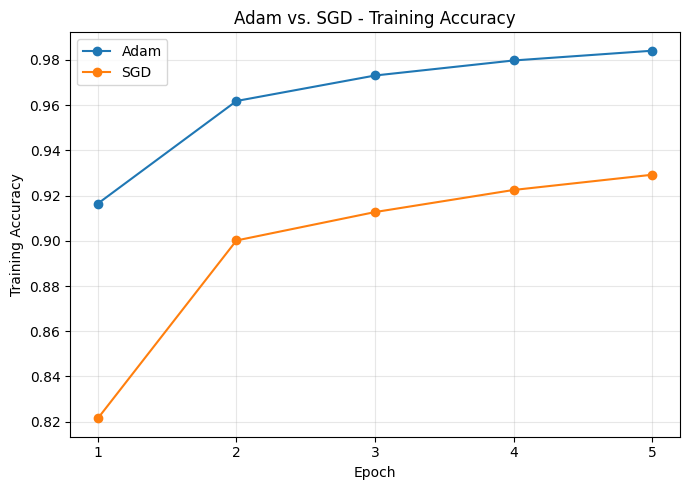

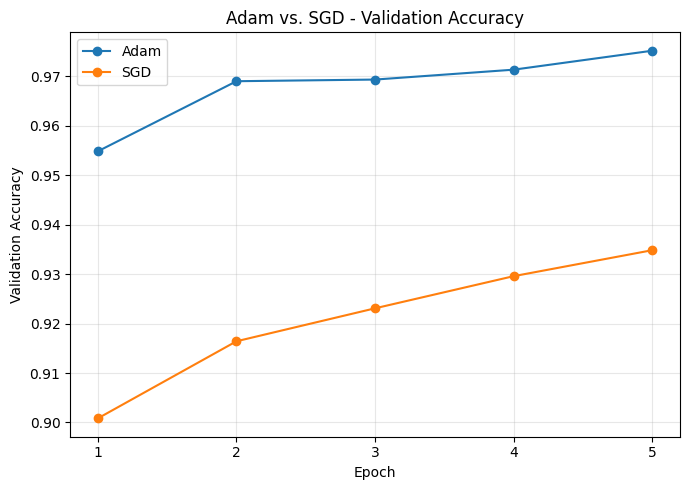

In [5]:
# 1. Load the MNIST dataset.
# MNIST contains 28 × 28 grayscale images of handwritten digits from 0 to 9.
# It is already divided into training and test datasets.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# Normalize the image pixel values from 0–255 to 0–1.
# This keeps the input values on a smaller scale, which helps the neural network train more efficiently.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)



# 2. Train two models: one with Adam and another with SGD.
#
# Create a function that builds the neural network.
# Both Adam and SGD models will use this same structure, so that the optimizer is the main difference between the two experiments.
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),

        # Convert each 28 × 28 image into a 1D vector of 784 values
        # so that it can be processed by the Dense layers.
        tf.keras.layers.Flatten(),

        # Hidden layer that learns patterns from the handwritten digits.
        tf.keras.layers.Dense(128, activation="relu"),

        # Output layer with 10 neurons representing digits 0 through 9.
        tf.keras.layers.Dense(10, activation="softmax")
    ])


# === Adam Model ===

# Create and compile the first model using Adam.
adam_model = create_model()

adam_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the Adam model for 5 epochs.
adam_history = adam_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# === SGD Model ===

# Create another model with the exact same structure, but use SGD as the optimizer.
sgd_model = create_model()
sgd_model.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the SGD model under the same conditions as Adam
# to make the comparison fair.
sgd_history = sgd_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# 3. Compare the training and validation accuracy trends.
# The recorded accuracy from each epoch is stored in the history
# returned when each model was trained.

epochs = range(1, 6)


# Compare training accuracy.
plt.figure(figsize=(7, 5))
plt.plot(epochs, adam_history.history["accuracy"], marker="o", label="Adam")
plt.plot(epochs, sgd_history.history["accuracy"], marker="o", label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Adam vs. SGD - Training Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Compare validation accuracy.
plt.figure(figsize=(7, 5))
plt.plot(epochs, adam_history.history["val_accuracy"], marker="o", label="Adam")
plt.plot(epochs, sgd_history.history["val_accuracy"], marker="o", label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Adam vs. SGD - Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
Both optimizers improved over the five epochs, but Adam learned faster and achieved higher training and validation accuracy than SGD. By epoch 5, Adam reached approximately 98.4% training accuracy and 97.5% validation accuracy, while SGD reached approximately 92.9% training accuracy and 93.5% validation accuracy. Under the same training conditions, Adam therefore converged faster than SGD.

## 4. Train a Neural Network and Log to TensorBoard
This task demonstrates how TensorBoard can be used to monitor a neural network during training. The MNIST dataset is loaded and preprocessed, a simple neural network is trained for five epochs, and TensorBoard logging is enabled so that training and validation accuracy and loss can be visualized and compared.

In [6]:
from datetime import datetime


# 1. Load the MNIST dataset and preprocess it.
# MNIST contains grayscale images of handwritten digits from 0 to 9.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# Normalize pixel values from 0–255 to 0–1.
# Keeping the input values on a smaller scale helps the neural network train more efficiently and consistently.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)



# 2. Train a simple neural network model and enable TensorBoard logging.
# == Create a simple neural network model.
# Flatten converts each 28 × 28 image into a 1D vector of 784 values.
# The hidden Dense layer learns patterns in the images.
# The output layer has 10 neurons, one for each digit from 0 to 9.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


# Compile the model.
# Adam updates the model's weights during training.
# Sparse Categorical Cross-Entropy is used because the MNIST labels
# are integers from 0 to 9 rather than one-hot encoded vectors.
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


# == Enable TensorBoard logging
# Create a unique folder for this training run.
# The timestamp prevents a new run from overwriting previous TensorBoard logs.
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")


# TensorBoard callback records training information such as
# accuracy and loss after each epoch.
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)


# Train the model for 5 epochs.
# validation_split=0.2 keeps 20% of the training data aside
# so that validation accuracy and loss can be monitored.
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[tensorboard_callback],
    verbose=1
)

print("\nTensorBoard logs stored in:", log_dir)


# 3. Launch TensorBoard and Analyze Loss and Accuracy Trends
%load_ext tensorboard
%tensorboard --logdir logs/fit

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9203 - loss: 0.2817 - val_accuracy: 0.9528 - val_loss: 0.1651
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9631 - loss: 0.1260 - val_accuracy: 0.9624 - val_loss: 0.1293
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9743 - loss: 0.0853 - val_accuracy: 0.9709 - val_loss: 0.0953
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9807 - loss: 0.0640 - val_accuracy: 0.9730 - val_loss: 0.0957
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0487 - val_accuracy: 0.9753 - val_loss: 0.0901

TensorBoard logs stored in: logs/fit/20260907-190240


### Observation
The MNIST dataset was successfully loaded and normalized before training a simple neural network for 5 epochs using the Adam optimizer. TensorBoard logging was enabled, and the training information was stored in the logs/fit/ directory as required. TensorBoard was then used to visualize and compare the model's training and validation performance.

During training, accuracy improved while loss decreased. Training accuracy increased from approximately 92.0% to 98.5%, while validation accuracy increased from approximately 95.3% to 97.5%. Training loss decreased from approximately 0.282 to 0.049, and validation loss decreased from approximately 0.165 to 0.090. These trends show that the model learned effectively during the five epochs and continued to perform well on the validation data. There was no clear indication of overfitting within the five epochs because validation accuracy improved overall while validation loss decreased.

## 4.1 Analysis Questions

### 1. What patterns do you observe in the training and validation accuracy curves?
Both training and validation accuracy generally increased as the number of epochs increased, showing that the model was learning. Training accuracy reached about 98.6%, while validation accuracy reached about 97.5%. Since both remained high and relatively close, the model performed well on both the training and validation data.

### 2. How can you use TensorBoard to detect overfitting?
TensorBoard can help detect overfitting by comparing the training and validation curves. If training accuracy continues to increase while validation accuracy stops improving or decreases, and training loss continues to decrease while validation loss begins to increase, the model may be overfitting.

### 3. What happens when you increase the number of epochs?
Increasing the number of epochs gives the model more opportunities to learn and may improve its accuracy. However, if training continues for too many epochs, the model may begin to overfit, in which training performance continues to improve while validation performance stops improving or becomes worse.